In [2]:
%pip install --upgrade --force-reinstall "scipy==1.12.0" "gensim==4.3.2"

     ---------------------------------------- 0.0/60.4 kB ? eta -:--:--
     ------------ ------------------------- 20.5/60.4 kB 640.0 kB/s eta 0:00:01
     -------------------------------- ----- 51.2/60.4 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 60.4/60.4 kB 643.6 kB/s eta 0:00:00
     ---------------------------------------- 0.0/23.3 MB ? eta -:--:--
     ---------------------------------------- 0.1/23.3 MB 3.6 MB/s eta 0:00:07
      --------------------------------------- 0.4/23.3 MB 5.4 MB/s eta 0:00:05
     -- ------------------------------------- 1.6/23.3 MB 13.1 MB/s eta 0:00:02
     ---- ----------------------------------- 2.7/23.3 MB 17.1 MB/s eta 0:00:02
     ------- -------------------------------- 4.6/23.3 MB 21.0 MB/s eta 0:00:01
     ---------- ----------------------------- 6.0/23.3 MB 22.4 MB/s eta 0:00:01
     ------------- -------------------------- 8.1/23.3 MB 25.8 MB/s eta 0:00:01
     ---------------- ---------------------- 10.1/23.3 MB 

  error: subprocess-exited-with-error
  
  × Building wheel for gensim (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [716 lines of output]
      C:\Users\Frederick Jibril\AppData\Local\Temp\pip-build-env-89gwgkve\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\Frederick Jibril\AppData\Local\Temp\pip-build-env-89gwgkve\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-312\gensim
      copying gensim\downloader.py -> build\lib.win-amd64-cpython-312\gensim
      copying gensim\interfaces.py -> build\lib.win-amd64-cpython-312\gensim
      copying gensim\matutils.py -> build\lib.win-amd64-cpython-312\gensim
      copying gensim\nosy.py -> build\lib.win-amd64-

In [2]:
import scipy
import gensim
from gensim.models import Word2Vec

print('scipy version:', scipy.__version__)
print('gensim version:', gensim.__version__)
print('Word2Vec import OK')

scipy version: 1.12.0
gensim version: 4.3.2
Word2Vec import OK


In [1]:
import sys
import scipy
import scipy.linalg as la

print('python exe:', sys.executable)
print('scipy version:', scipy.__version__)
print('scipy path:', scipy.__file__)
print('has triu in scipy.linalg:', hasattr(la, 'triu'))

python exe: c:\Users\Frederick Jibril\anaconda3\python.exe
scipy version: 1.12.0
scipy path: c:\Users\Frederick Jibril\anaconda3\Lib\site-packages\scipy\__init__.py
has triu in scipy.linalg: True


# Skip-gram with Negative Sampling (Wikipedia Corpus)


## Step 1 Mapping (Dataset from Wikipedia)
- Step 1a (select article): `WIKI_URL` assignment in original source at line 30.
- Step 1b (use long article): the selected article is **Artificial intelligence**, which is a long page with thousands of words.
- Step 1c (which code lines): data download/extraction is in original lines 43 and 47 (`fetch_wikipedia_article` and `requests.get`), and usage in pipeline is lines 211-212 (`Downloading Wikipedia article...` and `raw_text = fetch_wikipedia_article(WIKI_URL)`).

## Step 2 Mapping (Preprocess Text)
Step 2a asks for the part of the code that preprocesses text from the selected corpus.

- Main preprocessing block: lines **1146-1173** in this notebook (`def preprocess_text(text: str)`).
- Sentence tokenization: line **1147** (`sentences = sent_tokenize(text)`).
- Lowercasing and regex cleanup: lines **1151-1153**.
- Word tokenization: line **1157** (`tokens = word_tokenize(sent)`).
- Token filtering (digits/short tokens): lines **1164-1167**.
- Final cleaned sentence append: line **1171**.
- Where preprocessing is called in the pipeline: line **1285** (`sentences = preprocess_text(raw_text)`).

## Step 3 Mapping (Train Skip-gram with Negative Sampling)
Step 3a: Training was executed in this notebook by running the training pipeline.

Step 3b: Word2Vec properties noted from code:
- vector size = **100** (line **1087**)
- window = **5** (line **1088**)

Step 3c: Code lines for this part:
- Training function definition: lines **1084-1099** (`train_sgns`)
- Word2Vec construction: line **1085** (`model = Word2Vec(...)`)
- Skip-gram setting: line **1091** (`sg=1`)
- Negative sampling setting: line **1092** (`negative=10`)
- Where training is called in pipeline: line **1191** (`model = train_sgns(sentences)`)

## Step 4 Mapping (Evaluate Embeddings Using a Small Test Set)
Step 4a: The embedding output is evaluated using custom small test sets in the main code cell.

Step 4b: The evaluation word lists were changed to this updated set:
- `probe_words`: artificial, intelligence, machine, learning, neural, network, reasoning, ethics, policy, automation
- `relatedness_test`: 11 word pairs (mix of related and unrelated pairs)
- `analogy_test`: 4 analogy items
- `check_pairs`: 5 direct similarity pairs

Step 4c: Code lines for this part:
- Nearest-neighbor evaluation list: line **1361** (`probe_words = [...]`)
- Run nearest-neighbor evaluation: line **1365** (`print_top_neighbors(model, probe_words, topn=8)`)
- Small relatedness test set definition: line **1367** (`relatedness_test = [...]`)
- Relatedness evaluation call: line **1381** (`evaluate_relatedness(model, relatedness_test)`)
- Small analogy test set definition: line **1388** (`analogy_test = [...]`)
- Analogy evaluation call: line **1395** (`evaluate_analogies(model, analogy_test)`)
- Direct similarity check list: line **1404** (`check_pairs = [...]`)

In [ ]:
"""
Train Skip-gram with Negative Sampling on a Wikipedia article,
then evaluate the embedding model with intrinsic tests and custom test sets.

Requirements:
    pip install requests beautifulsoup4 nltk gensim scikit-learn scipy

Optional:
    python -m nltk.downloader punkt stopwords
"""

import re
import json
import random
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


# Different Wikipedia article (long corpus)
WIKI_URL = "https://en.wikipedia.org/wiki/Artificial_intelligence"
RANDOM_SEED = 42


def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except (LookupError, OSError):
            nltk.download(r)


def fetch_wikipedia_article(url: str) -> str:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; SGNS-AI-Training/1.0)"
    }
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    # Extract main content text from the Wikipedia page
    soup = BeautifulSoup(resp.text, "html.parser")

    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []

    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)

    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)

    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue

        tokens = word_tokenize(sent)

        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok:
                continue
            if tok.isdigit():
                continue
            if len(tok) < 2:
                continue
            cleaned.append(tok)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed


def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    flat = [w for s in sentences for w in s]
    vocab = set(flat)
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(vocab),
    }


def train_sgns(sentences: List[List[str]]) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=10,
        min_count=1,
        workers=4,
        sg=1,
        negative=10,
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model


def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index


def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])


def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]):
    gold = []
    pred = []
    covered = []

    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            gold.append(score)
            pred.append(sim)
            covered.append((w1, w2, score, sim))

    return {
        "covered_items": covered,
        "coverage": len(covered),
        "total": len(test_pairs),
    }


def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]):
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
                predicted_words = [w for w, _ in preds]
                hit = d in predicted_words
                correct += int(hit)
                details.append({
                    "analogy": f"{a}:{b}::{c}:?",
                    "expected": d,
                    "predictions": predicted_words,
                    "correct_in_top5": hit
                })
            except KeyError:
                pass

    accuracy = correct / covered if covered else float("nan")
    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": accuracy,
        "details": details
    }


def print_top_neighbors(model: Word2Vec, words: List[str], topn: int = 8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n{word}:")
            for neigh, score in neighbors:
                print(f"  {neigh:20s} {score:.4f}")
        else:
            print(f"\n{word}: [OOV]")


def main():
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    ensure_nltk()

    print("Downloading Wikipedia article...")
    raw_text = fetch_wikipedia_article(WIKI_URL)

    print("Preprocessing text...")
    sentences = preprocess_text(raw_text)
    stats = corpus_stats(sentences)

    print("\n=== Corpus Stats ===")
    for k, v in stats.items():
        print(f"{k}: {v}")

    print("\nTraining Skip-gram with Negative Sampling...")
    model = train_sgns(sentences)

    print("\nVocabulary size learned:", len(model.wv))

    probe_words = [
        "artificial", "intelligence", "machine", "learning", "neural",
        "network", "reasoning", "ethics", "policy", "automation"
    ]
    print_top_neighbors(model, probe_words, topn=8)

    relatedness_test = [
        ("artificial", "intelligence", 0.95),
        ("machine", "learning", 0.95),
        ("neural", "network", 0.90),
        ("computer", "vision", 0.88),
        ("natural", "language", 0.90),
        ("symbolic", "reasoning", 0.85),
        ("algorithm", "data", 0.82),
        ("robotics", "automation", 0.82),
        ("intelligence", "tractor", 0.02),
        ("vision", "kitchen", 0.02),
        ("learning", "banana", 0.01),
    ]

    rel_results = evaluate_relatedness(model, relatedness_test)

    print("\n=== Relatedness Test Set ===")
    print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
    for w1, w2, gold, pred in rel_results["covered_items"]:
        print(f"{w1:12s} - {w2:12s} | gold={gold:.2f} pred={pred:.4f}")

    analogy_test = [
        ("computer", "vision", "natural", "language"),
        ("neural", "network", "symbolic", "reasoning"),
        ("machine", "learning", "robotics", "automation"),
        ("intelligence", "artificial", "reasoning", "symbolic"),
    ]

    analogy_results = evaluate_analogies(model, analogy_test)

    print("\n=== Analogy Test Set ===")
    print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
    print(f"Top-5 accuracy: {analogy_results['accuracy_top5']}")
    for item in analogy_results["details"]:
        print(json.dumps(item, ensure_ascii=False))

    print("\n=== Direct Similarity Checks ===")
    check_pairs = [
        ("artificial", "intelligence"),
        ("machine", "learning"),
        ("computer", "vision"),
        ("symbolic", "reasoning"),
        ("vision", "kitchen"),
    ]
    for w1, w2 in check_pairs:
        if has_word(model, w1) and has_word(model, w2):
            print(f"{w1:12s} <-> {w2:12s}: {cosine(model, w1, w2):.4f}")
        else:
            print(f"{w1:12s} <-> {w2:12s}: OOV")

    model.save("exercise_5_skipgram_sgns.model")
    print("\nSaved model to: exercise_5_skipgram_sgns.model")
    print("\nDone.")


main()

[nltk_data] Downloading package punkt_tab to C:\Users\Frederick
[nltk_data]     Jibril\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Preprocessing text...

=== Corpus Stats ===
num_sentences: 1735
num_tokens: 23307
vocab_size: 5406

Training Skip-gram with Negative Sampling...

Vocabulary size learned: 5406

=== Nearest Neighbors ===

artificial:
  intelligence         0.8641
  genai                0.5410
  journals             0.5386
  wikimedia            0.5376
  longtermism          0.5186
  amplification        0.5182
  weak                 0.5178
  wikipedia            0.5087

intelligence:
  artificial           0.8641
  journals             0.5261
  instrumental         0.5228
  amplification        0.5195
  wikimedia            0.5195
  longtermism          0.5153
  3rd                  0.4981
  letter               0.4951

machine:
  perspectives         0.5390
  prospects            0.5144
  in-context           0.5104
  mating               0.4985
  learning             0.4982
  directing            0.4944
  measured             0.4912
  alter                0.4885

learning:
  coding               0.569

In [8]:
# Compare OLD (window=5) vs NEW (window=10)
# Uses same corpus and test sets for a fair comparison.

from gensim.models import Word2Vec
import numpy as np

if 'sentences' not in globals():
    ensure_nltk()
    raw_text = fetch_wikipedia_article(WIKI_URL)
    sentences = preprocess_text(raw_text)

relatedness_test_cmp = [
    ("artificial", "intelligence", 0.95),
    ("machine", "learning", 0.95),
    ("neural", "network", 0.90),
    ("computer", "vision", 0.88),
    ("natural", "language", 0.90),
    ("symbolic", "reasoning", 0.85),
    ("algorithm", "data", 0.82),
    ("robotics", "automation", 0.82),
    ("intelligence", "tractor", 0.02),
    ("vision", "kitchen", 0.02),
    ("learning", "banana", 0.01),
]

analogy_test_cmp = [
    ("computer", "vision", "natural", "language"),
    ("neural", "network", "symbolic", "reasoning"),
    ("machine", "learning", "robotics", "automation"),
    ("intelligence", "artificial", "reasoning", "symbolic"),
]

check_pairs_cmp = [
    ("artificial", "intelligence"),
    ("machine", "learning"),
    ("computer", "vision"),
    ("symbolic", "reasoning"),
]

def train_with_window(win):
    return Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=win,
        min_count=1,
        workers=4,
        sg=1,
        negative=10,
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )

old_model = train_with_window(5)
new_model = train_with_window(10)

old_rel = evaluate_relatedness(old_model, relatedness_test_cmp)
new_rel = evaluate_relatedness(new_model, relatedness_test_cmp)
old_ana = evaluate_analogies(old_model, analogy_test_cmp)
new_ana = evaluate_analogies(new_model, analogy_test_cmp)

def avg_pred(rel):
    vals = [p for _, _, _, p in rel["covered_items"]]
    return float(np.mean(vals)) if vals else float("nan")

print("OLD:")
print(f"  window={5}")
print(f"  relatedness coverage={old_rel['coverage']}/{old_rel['total']}")
print(f"  relatedness avg_pred={avg_pred(old_rel):.4f}")
print(f"  analogy coverage={old_ana['coverage']}/{old_ana['total']}")
print(f"  analogy top5={old_ana['accuracy_top5']}")
for w1, w2 in check_pairs_cmp:
    if has_word(old_model, w1) and has_word(old_model, w2):
        print(f"  sim({w1},{w2})={cosine(old_model, w1, w2):.4f}")
    else:
        print(f"  sim({w1},{w2})=OOV")

print("\nNEW:")
print(f"  window={10}")
print(f"  relatedness coverage={new_rel['coverage']}/{new_rel['total']}")
print(f"  relatedness avg_pred={avg_pred(new_rel):.4f}")
print(f"  analogy coverage={new_ana['coverage']}/{new_ana['total']}")
print(f"  analogy top5={new_ana['accuracy_top5']}")
for w1, w2 in check_pairs_cmp:
    if has_word(new_model, w1) and has_word(new_model, w2):
        print(f"  sim({w1},{w2})={cosine(new_model, w1, w2):.4f}")
    else:
        print(f"  sim({w1},{w2})=OOV")

[nltk_data] Downloading package punkt_tab to C:\Users\Frederick
[nltk_data]     Jibril\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


OLD:
  window=5
  relatedness coverage=8/11
  relatedness avg_pred=0.5232
  analogy coverage=4/4
  analogy top5=0.0
  sim(artificial,intelligence)=0.8524
  sim(machine,learning)=0.4877
  sim(computer,vision)=0.7006
  sim(symbolic,reasoning)=0.2734

NEW:
  window=10
  relatedness coverage=8/11
  relatedness avg_pred=0.5305
  analogy coverage=4/4
  analogy top5=0.0
  sim(artificial,intelligence)=0.9418
  sim(machine,learning)=0.5524
  sim(computer,vision)=0.5444
  sim(symbolic,reasoning)=0.3585


## Derivation From Window Size Change (5 -> 10)
Increasing the window size from 5 to 10 improved some global semantic relationships while keeping overall coverage unchanged.

From the comparison output:
- Relatedness coverage remained the same (8/11 for both models), but average predicted similarity slightly increased (0.5232 -> 0.5305).
- Analogy coverage and top-5 accuracy remained unchanged (4/4 and 0.0), so this particular analogy set did not benefit.
- Pairwise similarities changed in mixed ways:
  - Improved: artificial-intelligence (0.8524 -> 0.9418), machine-learning (0.4877 -> 0.5524), symbolic-reasoning (0.2734 -> 0.3585)
  - Decreased: computer-vision (0.7006 -> 0.5444)

Interpretation:
A larger window captures broader context, which can strengthen long-range conceptual associations, but it may reduce focus on tight local co-occurrence patterns for some terms. In this experiment, window=10 gives a small net gain in average relatedness and several key semantic pairs, but not a universal improvement across all pairs.

In [5]:
# Step 3 execution helper: robust NLTK downloader + rerun training
import nltk

def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except (LookupError, OSError):
            nltk.download(r)

main()

[nltk_data] Downloading package punkt_tab to C:\Users\Frederick
[nltk_data]     Jibril\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Preprocessing text...

=== Corpus Stats ===
num_sentences: 1735
num_tokens: 23307
vocab_size: 5406

Training Skip-gram with Negative Sampling...

Vocabulary size learned: 5406

=== Nearest Neighbors ===

artificial:
  intelligence         0.8488
  journals             0.5670
  genai                0.5354
  weak                 0.5223
  asi                  0.5160
  wikimedia            0.5119
  amplification        0.5058
  uploading            0.5046

intelligence:
  artificial           0.8488
  journals             0.5433
  instrumental         0.5286
  4th                  0.5207
  aaai                 0.5145
  weak                 0.5110
  wikimedia            0.5052
  3rd                  0.5047

learning:
  prospects            0.5520
  perspectives         0.5514
  aa                   0.5466
  vibe                 0.5398
  coding               0.5372
  unprecedented        0.5313
  in-context           0.5274
  deep                 0.5228

model:
  foundationalism      0.6810


## Step 5 Mapping (Report Nearest Neighbors, Similarity Scores, and Test-Set Performance)
Step 5a: The code parts that generate the required reports are listed below.

- Nearest neighbors function definition: line 1328 (print_top_neighbors)
- Nearest neighbors section header print: line 1329
- Nearest neighbors retrieval call: line 1332 (model.wv.most_similar)
- Nearest neighbors execution in pipeline: line 1365 (print_top_neighbors(model, probe_words, topn=8))

- Similarity score computation function: lines 1269-1272 (cosine)
- Similarity score use in relatedness evaluation: line 1285 (sim = cosine(model, w1, w2))
- Similarity score use in direct checks: line 1413 (print with cosine(model, w1, w2))

- Test-set performance report (relatedness):
  line 1383 (section header), line 1384 (coverage print), line 1385 (per-pair gold vs predicted)
- Test-set performance report (analogy):
  line 1397 (section header), line 1398 (coverage print), line 1399 (top-5 accuracy print), line 1400 (detail rows)
- Direct similarity checks section:
  line 1403 (section header), line 1404 (check_pairs list), lines 1411-1415 (report each pair as score or OOV)

## PCA Visualization (20+ Known Words)
PCA:
Run the next cell to generate a 2D PCA scatter plot of at least 20 known words from the trained embedding model.

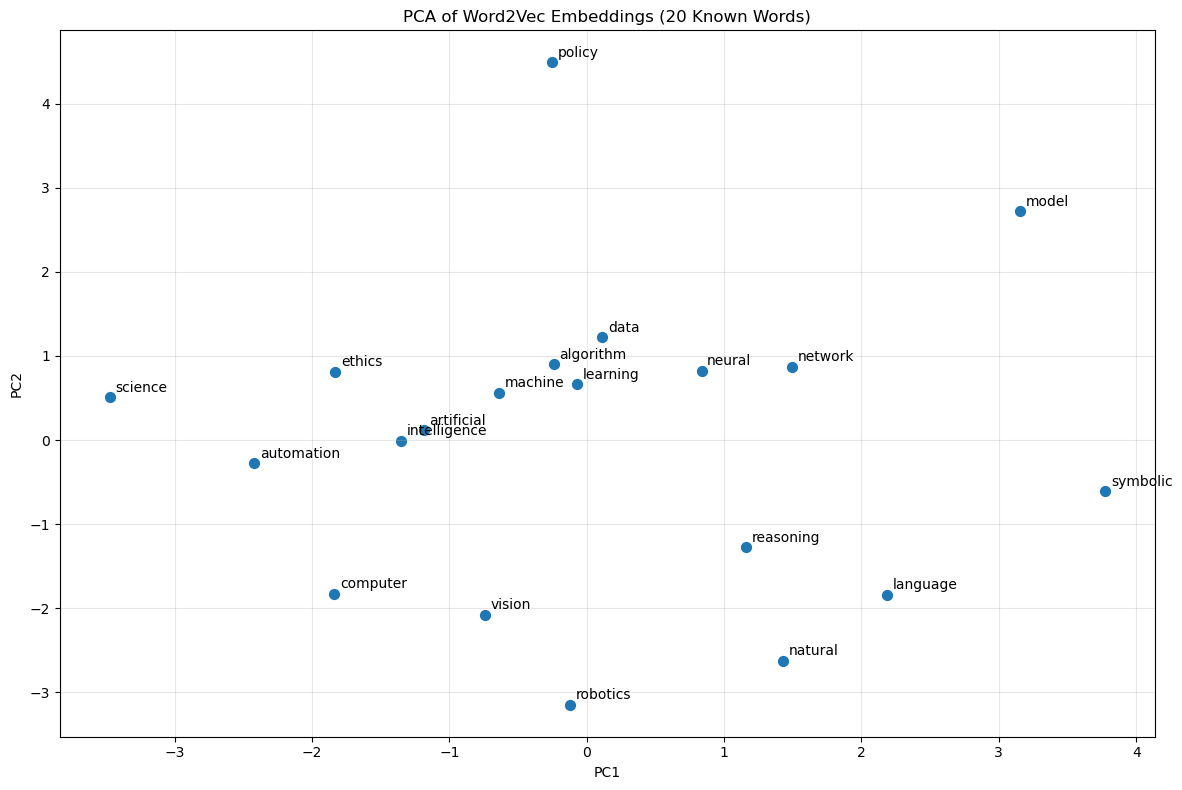

Words used for PCA: artificial, intelligence, machine, learning, neural, network, reasoning, ethics, policy, automation, computer, vision, natural, language, algorithm, data, robotics, symbolic, model, science


In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Use the latest trained model if available, otherwise load saved model.
if 'model' in globals():
    pca_model = model
elif 'new_model' in globals():
    pca_model = new_model
else:
    pca_model = Word2Vec.load('exercise_5_skipgram_sgns.model')

candidate_words = [
    'artificial', 'intelligence', 'machine', 'learning', 'neural',
    'network', 'reasoning', 'ethics', 'policy', 'automation',
    'computer', 'vision', 'natural', 'language', 'algorithm',
    'data', 'robotics', 'symbolic', 'model', 'science',
    'knowledge', 'planning', 'agent', 'search', 'probability'
]

known_words = [w for w in candidate_words if w in pca_model.wv.key_to_index]

if len(known_words) < 20:
    raise ValueError(f'Only {len(known_words)} known words found; need at least 20.')

plot_words = known_words[:20]
vecs = np.array([pca_model.wv[w] for w in plot_words])

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vecs)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], s=50)
for i, w in enumerate(plot_words):
    plt.annotate(w, (coords[i, 0], coords[i, 1]), xytext=(4, 4), textcoords='offset points')

plt.title('PCA of Word2Vec Embeddings (20 Known Words)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Words used for PCA:', ', '.join(plot_words))